In [ ]:
"""
TO DO
> verify if better to save functions outside this script as .py to run it with .bat and Windows Scheduler
> modify way to compute on/off times (off = round((total - on)/on))
> verify configparser on UIT
> clean it before one-take script run
"""

In [1]:
import pandas as pd
import configparser
import pylab as pl
import os
from datetime import datetime, timedelta

In [6]:
#Define a function to load R2 files
def get_directory_path(reactor):
    # Replace 'base_directory' with the base directory path where your CSV files are stored
    base_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'
    
    # Create a subdirectory name based on the 'i' index
    subdirectory_name = reactor
    
    # Combine the base directory and subdirectory to get the full path
    full_directory_path = os.path.join(base_directory, subdirectory_name)
    # Replace backslashes with forward slashes
    full_directory_path = full_directory_path.replace('\\', '/')
    
    return full_directory_path
reactor_number = 2
reactor = f'R{reactor_number}'
print(get_directory_path(reactor))

C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/R2


In [7]:
# Loop through the dates in the specified range and read the corresponding .csv files
# Get the current date and the previous date

#current_date = datetime.now().strftime('%Y_%m_%d')
#previous_date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')

start_date = datetime(2024, 1, 15)  # Start date in the format: YYYY, MM, DD
current_date = start_date.strftime('%Y-%m-%d')
previous_date = (start_date - timedelta(days=1)).strftime('%Y-%m-%d')

def read(date,reactor):
    directory_path = get_directory_path(reactor)
    file_path = os.path.join(directory_path, f'{date}_{reactor}.csv')  # Join directory path with file name
    file_path = file_path.replace('\\', '/')

    try:
        # Read the .csv file and append the dataframe to the list
        df = pd.read_csv(file_path,encoding='ISO-8859-1',delimiter = ';', 
                   parse_dates=['Timestamp'], dayfirst=True)
        print(f"Successfully read {date}_{reactor}")
    except FileNotFoundError:
        print(f"File {date} not found at path {file_path}.")
    return df

today = read(current_date,reactor)
yesterday = read(previous_date,reactor)

# Concatenate all the dataframes into one
combined_dataframe = pd.concat([today,yesterday], ignore_index=True)

Successfully read 2024-01-15_R2
Successfully read 2024-01-14_R2


In [5]:
gas_rate = combined_dataframe['2F1.1 [L/h]']
combined_dataframe['gas_ratio'] = combined_dataframe['2X11Q3 [V% CH4]']/combined_dataframe['2X11Q2 [V% CO2]']
#timestamp = data['Timestamp']

In [ ]:
# ---------------------------------- Oulier detection and replacement!!

In [6]:
#Moving average filter
def moving_average_filter(signal, window_size):
    kernel = np.ones(window_size) / window_size
    filtered_signal = convolve(signal, kernel, mode='valid')
    return np.concatenate((np.full(window_size - 1, np.nan), filtered_signal), axis=0)

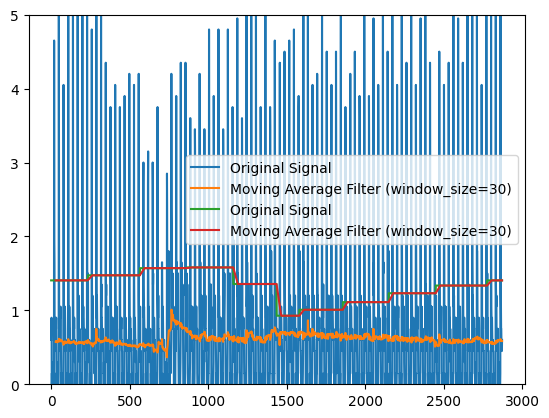

In [7]:
import numpy as np
from scipy.signal import convolve
window_size = 30

# Apply the moving average filter to the 'value' column
combined_dataframe['filtered_rate'] = moving_average_filter(combined_dataframe['2F1.1 [L/h]'], window_size)
combined_dataframe['filtered_ratio'] = moving_average_filter(combined_dataframe['gas_ratio'], window_size)

# Plotting the results
import matplotlib.pyplot as plt

plt.plot(gas_rate, label='Original Signal')
plt.plot(combined_dataframe['filtered_rate'], label=f'Moving Average Filter (window_size={window_size})')
plt.plot(combined_dataframe['gas_ratio'], label='Original Signal')
plt.plot(combined_dataframe['filtered_ratio'], label=f'Moving Average Filter (window_size={window_size})')
ax = plt.gca()
ax.set_ylim([0, 5])
plt.legend()
plt.show()

In [82]:
print(combined_dataframe['filtered_ratio'])

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
2869    1.405276
2870    1.405276
2871    1.405276
2872    1.405276
2873    1.405276
Name: filtered_ratio, Length: 2874, dtype: float64


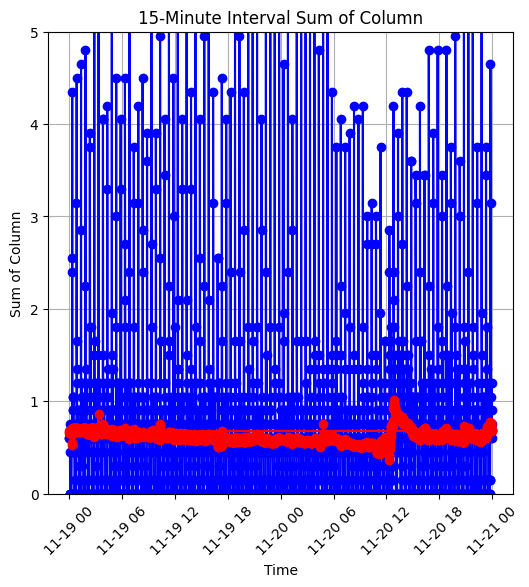

In [8]:
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import matplotlib.dates as mdates

# Plot the resampled data
plt.figure(figsize=(6, 6))
plt.plot(combined_dataframe['Timestamp'], combined_dataframe['2F1.1 [L/h]'], marker='o', linestyle='-', color='b')
plt.plot(combined_dataframe['Timestamp'], combined_dataframe['filtered_rate'], marker='o', linestyle='-', color='r')
plt.xlabel('Time')
plt.ylabel('Sum of Column')
plt.title('15-Minute Interval Sum of Column')
plt.xticks(rotation=45)
# Set x-axis limits with timestamps (from 10:30 AM to 12:30 PM)
#start_time = datetime(2023, 10, 19, 12, 0)
#end_time = datetime(2023, 10, 19, 22, 0)
#plt.xlim(mdates.date2num(start_time), mdates.date2num(end_time))
ax = plt.gca()
ax.set_ylim([0, 5])
#ax.set_xlim([15000,15015])
plt.grid()
plt.show()

In [77]:
#PI controller with saturation
#Choice to saturate the integral term or not
#Add on/off condition in the log!!
class PIController:
    def __init__(self, name, kp, ki, saturation_low=None, saturation_high=None, saturate_integral=True):
        self.name = name
        self.kp = kp
        self.ki = ki
        self.saturation_low = saturation_low
        self.saturation_high = saturation_high
        self.saturate_integral = saturate_integral
        self.log_df = pd.DataFrame(columns=['timestamp', 'error', 'integral','control_signal','selection'])

    def compute(self, error, dt, selection):
        #error = setpoint - feedback

        # Integral term
        integral = self.log_df['integral'].iloc[-1] if not self.log_df.empty else 0 #if not, assert?
        integral += error * dt

        # Apply saturation to the integral term if specified
        if self.saturate_integral:
            if self.saturation_low is not None and integral < self.saturation_low:
                integral = self.saturation_low
            elif self.saturation_high is not None and integral > self.saturation_high:
                integral = self.saturation_high

        # Calculate the control signal (output)
        #I need to add the time interval in the integral part!
        control_signal = self.kp * error + self.ki * integral

        # Apply saturation to the control signal
        if self.saturation_low is not None and control_signal < self.saturation_low:
            control_signal = self.saturation_low
        elif self.saturation_high is not None and control_signal > self.saturation_high:
            control_signal = self.saturation_high

        # Log the values
        timestamp = datetime.now()
        self.log_df = self.log_df.append({'timestamp': timestamp, 'error': error, 'integral': integral,
                                          'control_signal':control_signal,'selection': selection}, ignore_index=True)
        
        return control_signal
    
    def reset_state(self, desired_value):
        # Reset the state by appending a new row with the desired value ??
        timestamp = datetime.now()
        new_row = {'timestamp': timestamp, 'error': '-', 'integral': desired_value,'control_signal':'-','selection': str('reselected')}
        self.log_df = self.log_df.append(new_row, ignore_index=True)
    
    def save_state(self, filename=None):
        # If filename is not provided, use a default filename based on the controller's name
        if filename is None:
            filename = f"{self.name}_state.csv"
        
        # Save the log_df DataFrame to a file
        self.log_df.to_csv(filename, index=False)

    def load_state(self, filename=None):
        # If filename is not provided, use a default filename based on the controller's name
        if filename is None:
            filename = f"{self.name}_state.csv"
        
        # Load the log_df DataFrame from a file
        try:
            self.log_df = pd.read_csv(filename)
        except FileNotFoundError:
            print(f"State file '{filename}' not found. Initializing from default state.")

In [74]:
# Function to read setpoint values from a CSV file
def read_setpoints(file_path):
    setpoints = []
    with open(file_path, 'r') as file:
        reader = csv.reader(file,delimiter=';')
        next(reader)  # Skip header
        for row in reader:
            timestamp = datetime.strptime(row[0], "%d.%m.%Y %H:%M:%S")
            setpoint1 = float(row[1])
            setpoint2 = float(row[2])
            tresholdLow = float(row[3])
            tresholdHigh = float(row[4])
            #If condition of setpoint higher than tresholdLow to be added
            setpoints.append((timestamp, setpoint1,setpoint2,tresholdLow,tresholdHigh))
    return setpoints

# Function to get the setpoint at a specific time
def get_setpoint_at_time(setpoints, current_time):
    for timestamp, setpoint1, setpoint2,tresholdLow,tresholdHigh in reversed(setpoints):
        if current_time >= timestamp:
            return setpoint1,setpoint2,tresholdLow,tresholdHigh
    return setpoints[0][1],setpoints[0][2],setpoints[0][3],setpoints[0][4]  # Default to the first setpoint (?)

In [27]:
#ALTERNATIVE WAT TO CHECK FOR SETPOINTS
def get_setpoints(csv_file, timestamp):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(csv_file, parse_dates=['timestamp'])

    # Try to locate the timestamp in the 'timestamp' column
    mask = df['timestamp'] == timestamp
    if any(mask):
        # If found, return the setpoint values at that timestamp
        return df.loc[mask, ['feedback1_setpoint', 'feedback2_setpoint']].values.flatten()
    else:
        # If not found, return the setpoint values from the last row
        last_row = df.iloc[-1]
        return last_row[['feedback1_setpoint', 'feedback2_setpoint']].values.flatten()

In [62]:
class HysteresisComparator:
    def __init__(self, threshold_low, threshold_high):
        self.threshold_low = threshold_low
        self.threshold_high = threshold_high
        self.state = False  # Initial state

    def update(self, value):
        if value < self.threshold_low:
            self.state = False
        elif value > self.threshold_high:
            self.state = True
        # If the value is between the thresholds, maintain the current state
        #What if threshold_high<threshold_low ?

        return self.state
    
    def get_state_as_string(self):
        return str(self.state)

In [86]:
#RUN THE CONTROLLER
import os
import csv

last_row = combined_dataframe.iloc[-1]
measure1 = last_row['filtered_rate']
measure2 = 1/last_row['filtered_ratio']*(1+np.random.uniform(-0.5, +0.5))#,size=setpoints.shape) #If 0, assert?
#current_time = datetime.now()
current_time = last_row['Timestamp'] #Or time of run?

# File path for the setpoints CSV
setpoints_file_path = 'setpoints.csv'

# Read setpoints from the CSV file
#Check timestamp
setpoints = read_setpoints(setpoints_file_path)
setpoint1,setpoint2,threshold_low,threshold_high = get_setpoint_at_time(setpoints, current_time)

#Calculate current error
error1 = setpoint1 - measure1
error2 = setpoint2 - measure2
dt = 0.1  # Example time step

#Initialize the PI controller controllers for each run
controller1 = PIController(name = "Controller1", kp=0.1, ki=1e-3, saturation_low=-10, saturation_high=10,saturate_integral=False)
controller2 = PIController(name = "Controller2", kp=0.2, ki=1.5e-3, saturation_low=-10, saturation_high=10,saturate_integral=False)

# Load the state from the previous run
controller1.load_state()
controller2.load_state()

#REINIT
if not controller2.log_df.empty:
 controller2.log_df.loc[controller2.log_df.index[-1],'selection'] = controller2.log_df.at[controller2.log_df.index[-1],'selection'] == 'True'
prev_condition = controller2.log_df.iloc[-1]['selection'] if not controller2.log_df.empty else False # Initialize the previous condition
# Reset the state of controller1 using the last state of controller2 if the condition holds
#It adds a row in the log. Do I want it? It's not an actual calculation. 'error' vale?
#Dovrei cambiare struttura e, se condizione, non far leggere ultimo stato da file ma specificarlo direttamente
derired_value_controller1 = (float(controller2.log_df.iloc[-1]['control_signal'])-controller1.kp*error1)/controller1.ki if not controller2.log_df.empty else 0
derired_value_controller2 = (float(controller1.log_df.iloc[-1]['control_signal'])-controller2.kp*error2)/controller2.ki if not controller1.log_df.empty else 0
#Implement Hysteresis comparator!! ---------------------------------------------------------------------------
#From Modelica: y = not pre(y) and u > uHigh or pre(y) and u >= uLow;
#condition = True if measure2 > threshold else False
hysteresis_comp = HysteresisComparator(threshold_low=threshold_low, threshold_high=threshold_high)
condition = hysteresis_comp.update(measure2)
#condition = hysteresis_comp.get_state_as_string()

# Check for the edge condition change
if condition != prev_condition and prev_condition == False:
 # Reinitialize the state of controllers based on the edge condition
 controller2.reset_state(derired_value_controller2)
if condition != prev_condition and prev_condition == True:
 controller1.reset_state(derired_value_controller1)

# Calculate the control output
control_output1 = controller1.compute(error1, dt, not condition)
control_output2 = controller2.compute(error2, dt, condition)

# Save the state of controllers for the next run
controller1.save_state()
controller2.save_state()

#SWITCH
# Choose between the two control signals based on the condition
final_control_signal = control_output2 if condition else control_output1

# Save the log DataFrame to a CSV file
#controller1.log_df.to_csv('log_data.csv', index=False)
#controller2.log_df.to_csv('log_data.csv', index=False)
print(controller1.log_df)
print(controller2.log_df)

                    timestamp  error  integral       control_signal  \
0  2023-11-28 19:46:10.116233  2.415  0.241500            0.2417415   
1  2023-11-28 19:46:12.846436  2.415  0.483000             0.241983   
2  2023-11-28 19:46:14.246881  2.415  0.724500            0.2422245   
3  2023-11-28 19:48:11.883196      -  0.467045                    -   
4  2023-11-28 19:48:11.893510  2.415  0.708545  0.24220854541712478   
5  2023-11-28 19:51:53.357443  2.415  0.950045  0.24245004541712478   
6  2023-11-28 19:51:54.528969  2.415  1.191545  0.24269154541712476   
7  2023-11-28 19:51:58.341254  2.415  1.433045             0.242933   

    selection  
0        True  
1        True  
2       False  
3  reselected  
4        True  
5        True  
6        True  
7       False  
                    timestamp                  error    integral  \
0  2023-11-28 19:46:10.122465     0.0226844330129429    0.002268   
1  2023-11-28 19:46:12.858184     0.1117216703626117    0.013441   
2  2023-11-2

In [ ]:
#If the control_output is in L/h, I need to devide the required flowrate by 60 minutes/hour.

#To set arbitrary control output
#control_output=0.8

interval_minutes = 15
pump_dose_per_minute = 10

required_volume = 1000 * control_output / 60 * interval_minutes

on_minutes = max(0,int(required_volume / pump_dose_per_minute))

In [ ]:
def generate_binary_sequence(control_output, interval_minutes, pump_dose_per_minute):
    required_volume = 1000 * control_output / 60 * interval_minutes
    #Round to the nearest integer
    on_minutes = max(0,int(required_volume / pump_dose_per_minute))

    # Calculate the number of 'off' minutes between 'on' periods
    off_minutes = interval_minutes - on_minutes
    
    if off_minutes < 0:
        off_minutes = 0
        on_minutes = interval_minutes
    

    # Calculate the minimum gap needed between 'on' periods to avoid consecutiveness
    min_gap = np.ceil(off_minutes / (on_minutes))

    # Generate the binary sequence
    binary_sequence = np.zeros(interval_minutes)

    # Calculate the starting index for 'on' periods
    start_index = int(min_gap / 2)

    # Set 'on' periods with the desired gap
    for i in range(start_index, interval_minutes, int(min_gap) + 1):
        binary_sequence[i] = 1
        
    # Adjust the sum to ensure it's equal to on_minutes
    current_sum = int(np.sum(binary_sequence))
    diff = on_minutes - current_sum

    if diff > 0:
        # Distribute the remaining 'on' minutes
        remaining_indices = np.where(binary_sequence == 0)[0]
        binary_sequence[remaining_indices[:diff]] = 1
    elif diff < 0:
        # Reduce the 'on' minutes
        on_indices = np.where(binary_sequence == 1)[0]
        binary_sequence[on_indices[:abs(diff)]] = 0

    return on_minutes,off_minutes,min_gap,binary_sequence

In [ ]:
on_minutes,off_minutes,min_gap,binary_sequence = generate_binary_sequence(control_output, interval_minutes, pump_dose_per_minute)

In [ ]:
#Compute values to be placed in .ini file
#Range 0...86400 seconds
on_seconds = 60*on_minutes
off_seconds = interval_minutes*60 - on_seconds

In [ ]:
#Alternative way to create the binary_sequence
# Create a binary sequence with 'on_minutes' ones and the rest zeros
binary_sequence = np.zeros(interval_minutes)
binary_sequence[:on_minutes] = 1
# Shuffle the sequence to distribute 'on' values uniformly
np.random.shuffle(binary_sequence)

In [ ]:
import configparser
import os
import shutil
from datetime import datetime, timedelta
past_time = datetime(2023,10,9,16,14,6)
current_time = datetime.now()

def update_ini_file(input_config_file_path, input_directory, output_directory, on_seconds, off_seconds):
    # Read the original .ini file
    config = configparser.ConfigParser()
    config.read(input_config_file_path)

    # Replace 'your_section' and 'your_key' with the appropriate section and key in your .ini file
    #config['REACTOR1']['feedpumpontime'] = str(on_seconds)+',000000'
    #config['REACTOR1']['feedpumpofftime'] = str(off_seconds)+',000000'
    config['REACTOR2']['feedpumpontime'] = str(on_seconds)+',000000'
    config['REACTOR2']['feedpumpofftime'] = str(off_seconds)+',000000'
    #Alternative way to set parameters in .ini
    #config.set('REACTOR2', 'feedpumpontime', str(ciao))

    # Ensure the output directory exists; create it if necessary
    os.makedirs(output_directory, exist_ok=True)

    # Save the modified .ini file in the specified output directory
    output_file_name = f"Parameter_{current_time.strftime('%Y-%m-%d_%H-%M-%S')}.ini"
    output_file_path = os.path.join(output_directory, output_file_name)
    output_file_path = output_file_path.replace('\\', '/')
    with open(output_file_path, 'w') as configfile:
        config.write(configfile)

    # Make a copy of the modified .ini file in another directory
    #copy_file_name = file_name.replace('.ini','_copy.ini')
    copy_file_path = os.path.join(input_directory, output_file_name)
    copy_file_path = copy_file_path.replace('\\', '/')
    shutil.copyfile(output_file_path, copy_file_path)

# Example usage
output_directory =  'C:/Users/lenovo/impact/UIT controller/Bioreactor'

file_name = f"Parameter_{past_time.strftime('%Y-%m-%d_%H-%M-%S')}.ini"  # Updated date format
input_directory = 'C:/Users/lenovo/impact/UIT controller/'
file_path = os.path.join(input_directory, file_name)  # Join directory path with file name
input_config_file_path = file_path.replace('\\', '/')

update_ini_file(input_config_file_path, input_directory, output_directory, on_seconds, off_seconds)
